# 🟡 Project - Heart Disease with SVM Kernels (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

### Business question
Screen heart disease from 13 clinical features (real UCI CSV already living in
`data/heart.csv`). Compare kernels under a proper grid; then bend the decision
threshold for screening posture.

Full pipeline: load → EDA → processing → training → evaluation.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             recall_score, f1_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

### 2. Data loading (local canonical copy in data/)


In [2]:
heart = pd.read_csv(ML_ROOT / "data" / "heart.csv")
print(heart.shape); display(heart.head(3))

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1


### 3. Exploratory Data Analysis


missing: 0 | duplicated: 1

target balance: {1: 0.545, 0: 0.455}


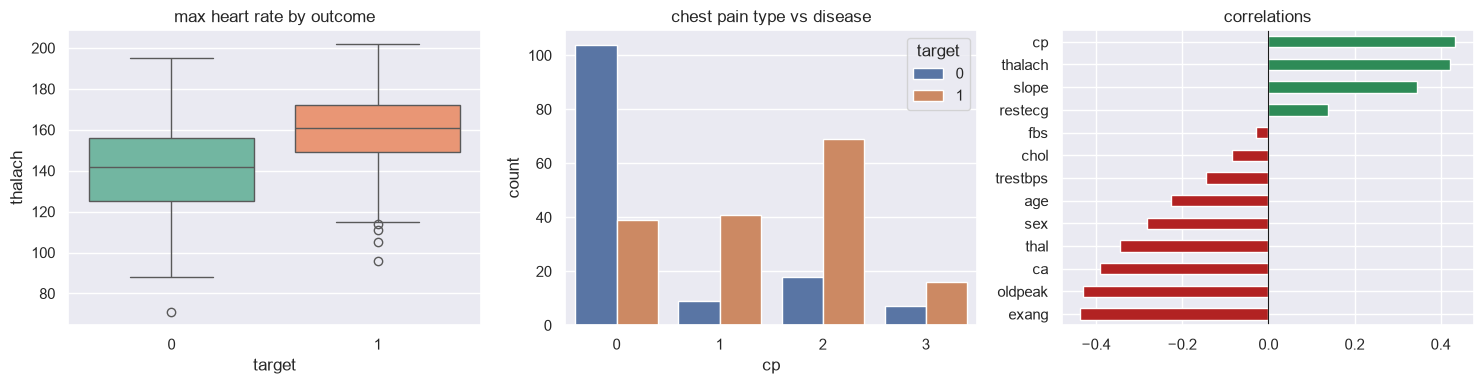

In [3]:
print("missing:", heart.isna().sum().sum(),
      "| duplicated:", heart.duplicated().sum())
print("\ntarget balance:", heart.target.value_counts(normalize=True).round(3).to_dict())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=heart, x="target", y="thalach", ax=axes[0],
            palette="Set2", hue="target", legend=False)
axes[0].set_title("max heart rate by outcome")
sns.countplot(data=heart, x="cp", hue="target", ax=axes[1])
axes[1].set_title("chest pain type vs disease")
corr = heart.corr()["target"].drop("target").sort_values()
colors = ["firebrick" if v < 0 else "seagreen" for v in corr]
corr.plot(kind="barh", color=colors, ax=axes[2])
axes[2].axvline(0, c="k", lw=.8); axes[2].set_title("correlations")
plt.tight_layout(); plt.show()

### 4. Data processing


In [4]:
y = heart.pop("target").values
X_tr, X_te, y_tr, y_te = train_test_split(
    heart.values.astype(float), y, test_size=.25,
    random_state=42, stratify=y)              # stratify keeps disease rate equal

### 5. Model training - kernel × C × gamma grid


In [5]:
grid = GridSearchCV(
    Pipeline([("sc", StandardScaler()), ("svm", SVC())]),
    {"svm__kernel": ["linear", "rbf"],
     "svm__C": [0.1, 0.5, 1, 5, 20],
     "svm__gamma": ["scale", 0.01, 0.05]},
    cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_tr, y_tr)

res = pd.DataFrame(grid.cv_results_)[["param_svm__kernel", "param_svm__C",
                                      "mean_test_score"]] \
        .sort_values("mean_test_score", ascending=False).head(8)
display(res.rename(columns={"mean_test_score": "cv_F1"}))

best = grid.best_estimator_
pred = best.predict(X_te)
cv = cross_val_score(best, X_tr, y_tr, cv=5).mean()
print(f"\ntest acc {accuracy_score(y_te, pred):.3f} "
      f"| F1 {f1_score(y_te, pred):.3f} | CV {cv:.3f}")

cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()
display(pd.DataFrame(cm, index=["true healthy", "true diseased"],
                     columns=["pred healthy", "pred diseased"]))

,param_svm__kernel,param_svm__C,cv_F1
9,rbf,0.5,0.876130
11,rbf,0.5,0.872254
15,rbf,1.0,0.869465
7,rbf,0.5,0.869266
0,linear,0.1,0.868725
4,linear,0.1,0.868725
2,linear,0.1,0.868725
17,rbf,1.0,0.867392



test acc 0.789 | F1 0.826 | CV 0.855


,pred healthy,pred diseased
true healthy,22,13
true diseased,3,38


### 5b. Screening posture - move the margin line


In [6]:
dec = best.decision_function(X_te)             # signed distance to the street
rows = []
for t in [-0.5, -0.25, 0.0, 0.25]:
    lab = (dec >= t).astype(int)
    cmt = confusion_matrix(y_te, lab)
    rows.append({"margin_threshold": t,
                 "recall_diseased": round(recall_score(y_te, lab), 3),
                 "false_alarms": int(cmt[0, 1]),
                 "missed": int(cmt[1, 0])})
display(pd.DataFrame(rows))

,margin_threshold,recall_diseased,false_alarms,missed
0,-0.50,0.976,17,1
1,-0.25,0.951,15,2
2,0.00,0.927,13,3
3,0.25,0.756,13,10


### 6. Findings & recommendation

1. Linear ≈ RBF within noise - modest feature space hides no deep curves.
2. Threshold < 0 trades alarms for fewer missed patients: the screening trade.
3. F1 ≈ 0.85-0.88 ceiling matches logistic/RF modules - dataset-bound.